# Basin Centroids from Shapefile

Extract geographic centroids for all 24 CO₂ injection basins in China.

**Source 1 (20 basins):** polygon centroids computed from `sed_basins/sed_basins.shp` using Shapely.  
**Source 2 (4 basins):** coordinates derived from published literature for basins absent from the shapefile:

| Basin | Literature source |
|---|---|
| Sanjiang Basin | [Gravity & magnetic features of the Sanjiang Basin, *J. Geophysics & Engineering* (2012)](https://academic.oup.com/jge/article/9/2/147/5128387) |
| Yingen-Ejina Basin | [Gravity & magnetic anomalies of Yingen-Ejinaqi Basin, *J. Geophysics & Engineering* (2024)](https://academic.oup.com/jge/article/21/1/304/7492809) |
| Hehuai Basin | [CO2 Storage Prospectivity of Selected Sedimentary Basins in China and SE Asia, APEC (2005)](https://www.apec.org/Publications/2005/06/CO2-Storage-Prospectivity-of-Selected-Sedimentary-Basins-in-the-Region-of-China-and-South-East-Asia) — identifies it as the southern part of the North China Basin |
| Qiongdongnan Basin | [Hyperextended crustal structure of the Qiongdongnan Basin, *Science China Earth Sciences* (2022)](https://doi.org/10.1007/s11430-021-9894-7) |

In [29]:
import shapefile
import numpy as np
import pandas as pd
from shapely.geometry import shape
from shapely.ops import unary_union
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

SHP_PATH = "sed_basins/sed_basins.shp"

In [30]:
# Load all shapefile records and preview
sf = shapefile.Reader(SHP_PATH)
print("Fields:", [f[0] for f in sf.fields[1:]])
print("Total records:", len(sf.records()))
print()
for i, r in enumerate(sf.records()):
    print(f"{i:>2}: {r[4]}")

Fields: ['AREA', 'PERIMETER', 'AGE_BASIN_', 'AGE_BASIN_', 'NAME', 'ERA']
Total records: 43

 0: Hailar Basin
 1: Songliao Basin
 2: Bayanhuxu-Eren Basin
 3: Junggar Basin
 4: Turpan-Hami Basin
 5: Tarim Basin
 6: Bohai Bay Basin
 7: Jiuquan-Minle Basin
 8: Ordos Basin
 9: Qaidam Basin
10: North Yellow Sea Basin
11: Quinshi-Linfen Basin
12: Northern South Yellow Sea Basin
13: Tsushima Basin
14: Northern Jiangsu-Southern South Yellow Sea Basin
15: East China Sea Shelf Basin
16: Tosa Bay Basin
17: Nanyang-Xiangfang Basin
18: Sichuan Basin
19: Miyazaki Basin
20: Okinawa Trough Basin
21: Lunpola-Baingoin Basin
22: Jianghan Basin
23: Dongting Basin
24: Amami Basin
25: Ryukyu Island Shimajiri Basin
26: Northwestern Taiwan Basin
27: Erhai Basin
28: Jinggu Basin
29: Bose Basin
30: Southwestern Taiwan Basin
31: Sanshui Basin
32: Zhujiangkou (Pearle R. Mouth) Basin
33: Beibu Gulf Basin
34: 
35: 
36: South Bijia Basin
37: North Shuangfeng Basin
38: North Shuangfeng Basin
39: North Shuangfeng Basin

In [31]:
# Split Bohai Bay Basin (record 6) into onshore and offshore parts.
# Uses Natural Earth 10m land polygons as the land/ocean mask.
# All other basins in BASIN_MAP are entirely onshore or offshore, so no splitting is needed.
_land_shp  = shpreader.natural_earth(resolution="10m", category="physical", name="land")
_land_geom = unary_union([g for g in shpreader.Reader(_land_shp).geometries()])

_bohai_full = shape(sf.shape(6).__geo_interface__)
_bohai_on   = _bohai_full.intersection(_land_geom)
_bohai_off  = _bohai_full.difference(_land_geom)

print(f"Bohai Bay onshore  centroid: ({_bohai_on.centroid.y:.4f} N, {_bohai_on.centroid.x:.4f} E)")
print(f"Bohai Bay offshore centroid: ({_bohai_off.centroid.y:.4f} N, {_bohai_off.centroid.x:.4f} E)")

# Stored here; picked up by the centroid computation cell below
GEOM_OVERRIDES = {
    "Bohai Bay Basin (onshore)":  _bohai_on,
    "Bohai Bay Basin (offshore)": _bohai_off,
}

Bohai Bay onshore  centroid: (38.1531 N, 117.0270 E)
Bohai Bay offshore centroid: (39.0081 N, 119.7405 E)


In [32]:
# Map each of the 24 target basins to shapefile record index(es).
# None = basin is absent from the shapefile; coordinates come from literature (see cell below).
# Bohai Bay Basin is split into onshore/offshore by the cell above; both still reference index 6
# so the shapefile polygon is drawn on the map, but centroids come from GEOM_OVERRIDES.
BASIN_MAP = [
    # (user name,                        shapefile index,  onshore/offshore)
    # --- Onshore ---
    ("Songliao Basin",                   1,        "onshore"),
    ("Turpan-Hami Basin",                4,        "onshore"),   # user spelled 'Tuepan-Hami'
    ("Subei Basin",                      14,       "onshore"),   # Northern Jiangsu–S. Yellow Sea Basin
    ("Bohai Bay Basin (onshore)",        6,        "onshore"),   # centroid from GEOM_OVERRIDES
    ("Qaidam Basin",                     9,        "onshore"),
    ("Nanxiang Basin",                   17,       "onshore"),   # Nanyang-Xiangfang Basin
    ("Sanjiang Basin",                   None,     "onshore"),
    ("Hailar Basin",                     0,        "onshore"),
    ("Jianghan Basin",                   22,       "onshore"),
    ("Tarim Basin",                      5,        "onshore"),
    ("Ordos Basin",                      8,        "onshore"),
    ("Yingen-Ejina Basin",               None,     "onshore"),
    ("Hehuai Basin",                     None,     "onshore"),
    ("Qinshui Basin",                    11,       "onshore"),   # Quinshi-Linfen Basin
    ("Erlian Basin",                     2,        "onshore"),   # Bayanhuxu-Eren Basin
    ("Junggar Basin",                    3,        "onshore"),
    ("Sichuan Basin",                    18,       "onshore"),
    # --- Offshore ---
    ("Bohai Bay Basin (offshore)",       6,        "offshore"),  # centroid from GEOM_OVERRIDES
    ("North Yellow Sea Basin",           10,       "offshore"),
    ("South Yellow Sea Basin",           12,       "offshore"),  # Northern South Yellow Sea Basin
    ("East China Sea Basin",             15,       "offshore"),
    ("Pearl River Mouth Basin",          32,       "offshore"),  # Zhujiangkou Basin
    ("Beibu Gulf Basin",                 33,       "offshore"),
    ("Qiongdongnan Basin",              None,      "offshore"),
]

print(f"Total target basins : {len(BASIN_MAP)}")
print(f"From shapefile      : {sum(1 for _, idx, _ in BASIN_MAP if idx is not None)}")
print(f"From literature     : {sum(1 for _, idx, _ in BASIN_MAP if idx is None)}")

Total target basins : 24
From shapefile      : 20
From literature     : 4


In [33]:
# Manually-researched centroids for the four basins absent from the shapefile.
#
# Sanjiang Basin
#   The basin occupies the convergence zone of the Heilong, Songhua, and Ussuri rivers in
#   NE Heilongjiang. The basin extent spans ~46–48 N, 130–134 E; centroid estimated from
#   the structural map in:
#   He et al. (2012), J. Geophysics & Engineering 9(2):147–157
#   https://academic.oup.com/jge/article/9/2/147/5128387
#
# Yingen-Ejina Basin
#   A 600 km (EW) × 75–255 km (NS) intracratonic basin in western Inner Mongolia.
#   Centroid estimated from basin outline figures in:
#   Wang et al. (2024), J. Geophysics & Engineering 21(1):304
#   https://academic.oup.com/jge/article/21/1/304/7492809
#
# Hehuai Basin
#   The APEC 2005 CO2 storage report lists it as "the southern part of the North China Basin,"
#   spanning Henan and Anhui provinces between the Yellow and Huai rivers (~32–36 N, 112–118 E).
#   APEC (2005) CO2 Storage Prospectivity of Selected Sedimentary Basins in China and SE Asia
#   https://www.apec.org/Publications/2005/06/CO2-Storage-Prospectivity-of-Selected-Sedimentary-Basins-in-the-Region-of-China-and-South-East-Asia
#
# Qiongdongnan Basin
#   A Cenozoic rift basin on the northern passive margin of the South China Sea, south of Hainan.
#   Reported extent: 108°40'–112°35' E, 16°50'–19°00' N (area ~80 000 km²).
#   Zhao et al. (2022), Science China Earth Sciences
#   https://doi.org/10.1007/s11430-021-9894-7

LITERATURE_CENTROIDS = {
    "Sanjiang Basin":     {"lon": 132.0, "lat": 47.0,
                           "source": "He et al. (2012), J. Geophys. Eng. 9(2):147 — basin extent 46–48 N, 130–134 E",
                           "url": "https://academic.oup.com/jge/article/9/2/147/5128387"},
    "Yingen-Ejina Basin": {"lon": 101.5, "lat": 41.5,
                           "source": "Wang et al. (2024), J. Geophys. Eng. 21(1):304 — basin 600 km EW, western Inner Mongolia",
                           "url": "https://academic.oup.com/jge/article/21/1/304/7492809"},
    "Hehuai Basin":       {"lon": 115.0, "lat": 34.0,
                           "source": "APEC (2005) CO2 Storage Prospectivity — southern North China Basin, ~32–36 N, 112–118 E",
                           "url": "https://www.apec.org/Publications/2005/06/CO2-Storage-Prospectivity-of-Selected-Sedimentary-Basins-in-the-Region-of-China-and-South-East-Asia"},
    "Qiongdongnan Basin": {"lon": 110.6, "lat": 17.9,
                           "source": "Zhao et al. (2022), Sci. China Earth Sci. — extent 108°40'–112°35' E, 16°50'–19°00' N",
                           "url": "https://doi.org/10.1007/s11430-021-9894-7"},
}

for name, info in LITERATURE_CENTROIDS.items():
    print(f"{name}: ({info['lat']:.2f} N, {info['lon']:.2f} E)")
    print(f"  {info['source']}")
    print()

Sanjiang Basin: (47.00 N, 132.00 E)
  He et al. (2012), J. Geophys. Eng. 9(2):147 — basin extent 46–48 N, 130–134 E

Yingen-Ejina Basin: (41.50 N, 101.50 E)
  Wang et al. (2024), J. Geophys. Eng. 21(1):304 — basin 600 km EW, western Inner Mongolia

Hehuai Basin: (34.00 N, 115.00 E)
  APEC (2005) CO2 Storage Prospectivity — southern North China Basin, ~32–36 N, 112–118 E

Qiongdongnan Basin: (17.90 N, 110.60 E)
  Zhao et al. (2022), Sci. China Earth Sci. — extent 108°40'–112°35' E, 16°50'–19°00' N



In [34]:
# Build Shapely geometries and compute centroids for all 24 basins.
# Priority: GEOM_OVERRIDES > shapefile polygon > literature coordinates.
shapes_list = sf.shapes()
geoms = [shape(s.__geo_interface__) for s in shapes_list]

records = []
for basin_name, idx, basin_type in BASIN_MAP:
    if basin_name in GEOM_OVERRIDES:
        # Bohai Bay split geometry
        geom = GEOM_OVERRIDES[basin_name]
        shp_name = sf.record(6)[4] + " (split by Natural Earth land mask)"
        c = geom.centroid
        records.append({
            "basin": basin_name,
            "type": basin_type,
            "lon": round(c.x, 4),
            "lat": round(c.y, 4),
            "source": "shapefile+split",
            "shapefile_name": shp_name,
            "notes": "Bohai Bay polygon intersected with Natural Earth 10m land to isolate onshore/offshore portion",
        })
    elif idx is None:
        lit = LITERATURE_CENTROIDS[basin_name]
        records.append({
            "basin": basin_name,
            "type": basin_type,
            "lon": lit["lon"],
            "lat": lit["lat"],
            "source": "literature",
            "shapefile_name": "—",
            "notes": lit["source"],
        })
    else:
        indices = [idx] if isinstance(idx, int) else idx
        shp_names = ", ".join(sf.record(i)[4] for i in indices)
        geom = geoms[indices[0]] if len(indices) == 1 else unary_union([geoms[i] for i in indices])
        c = geom.centroid
        records.append({
            "basin": basin_name,
            "type": basin_type,
            "lon": round(c.x, 4),
            "lat": round(c.y, 4),
            "source": "shapefile",
            "shapefile_name": shp_names,
            "notes": "",
        })

df = pd.DataFrame(records)
df.index = range(1, len(df) + 1)
df.index.name = "#"
df

,basin,type,lon,lat,source,shapefile_name,notes
#,,,,,,,
1,Songliao Basin,onshore,124.2489,45.5424,shapefile,Songliao Basin,
2,Turpan-Hami Basin,onshore,91.8474,42.7741,shapefile,Turpan-Hami Basin,
3,Subei Basin,onshore,120.2968,33.2802,shapefile,Northern Jiangsu-Southern South Yellow Sea Basin,
4,Bohai Bay Basin (onshore),onshore,117.0270,38.1531,shapefile+split,Bohai Bay Basin (split by Natural Earth land m...,Bohai Bay polygon intersected with Natural Ear...
5,Qaidam Basin,onshore,94.0675,37.4565,shapefile,Qaidam Basin,
6,Nanxiang Basin,onshore,112.3891,32.6284,shapefile,Nanyang-Xiangfang Basin,
7,Sanjiang Basin,onshore,132.0000,47.0000,literature,—,"He et al. (2012), J. Geophys. Eng. 9(2):147 — ..."
8,Hailar Basin,onshore,118.5403,48.9011,shapefile,Hailar Basin,
9,Jianghan Basin,onshore,112.9206,30.4742,shapefile,Jianghan Basin,


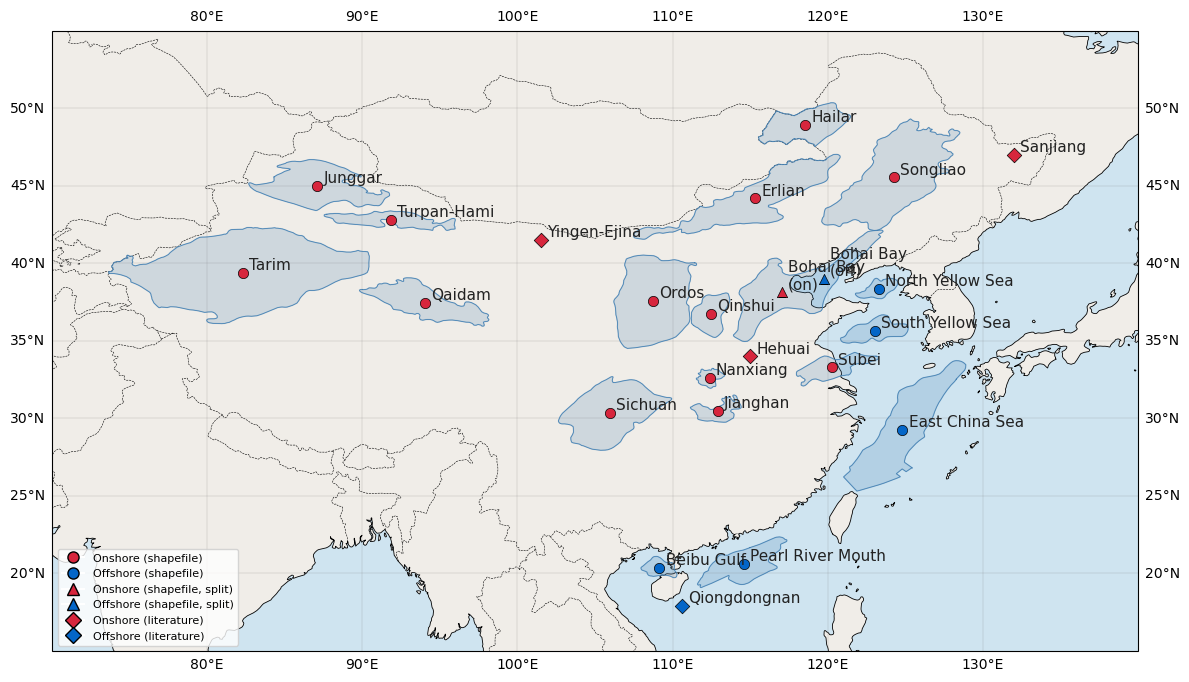

Saved basin_centroids_shapefile.png


In [35]:
# Map: shapefile polygon outlines + all 24 centroids
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
ax.set_extent([70, 140, 15, 55], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f0ede8", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#cfe4f0", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle="--", zorder=1)
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)

# Draw shapefile polygon outlines for matched basins
drawn_idx = set()
for _, idx, _ in BASIN_MAP:
    if idx is None:
        continue
    indices = [idx] if isinstance(idx, int) else idx
    for i in indices:
        if i in drawn_idx:
            continue
        drawn_idx.add(i)
        geom = geoms[i]
        polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for poly in polys:
            x, y = poly.exterior.xy
            ax.fill(x, y, alpha=0.2, color="steelblue", transform=ccrs.PlateCarree(), zorder=1)
            ax.plot(x, y, color="steelblue", linewidth=0.6, transform=ccrs.PlateCarree(), zorder=2)

# circle = raw shapefile centroid, triangle = split centroid, diamond = literature
marker_map = {"shapefile": "o", "shapefile+split": "^", "literature": "D"}
color_map  = {"onshore": "#d7263d", "offshore": "#0466c8"}

for row in df.itertuples():
    ax.scatter(
        row.lon, row.lat,
        s=55, marker=marker_map[row.source],
        c=color_map[row.type], edgecolors="k", linewidths=0.5,
        transform=ccrs.PlateCarree(), zorder=4,
    )
    label = (row.basin
              .replace(" Basin", "")
              .replace(" (onshore)", "\n(on)")
              .replace(" (offshore)", "\n(off)"))
    ax.text(
        row.lon + 0.4, row.lat + 0.2, label,
        fontsize=11, transform=ccrs.PlateCarree(), zorder=5, color="#222222",
    )

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d7263d", markeredgecolor="k", markersize=8, label="Onshore (shapefile)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#0466c8", markeredgecolor="k", markersize=8, label="Offshore (shapefile)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#d7263d", markeredgecolor="k", markersize=8, label="Onshore (shapefile, split)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#0466c8", markeredgecolor="k", markersize=8, label="Offshore (shapefile, split)"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#d7263d", markeredgecolor="k", markersize=8, label="Onshore (literature)"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#0466c8", markeredgecolor="k", markersize=8, label="Offshore (literature)"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=8)

#ax.set_title("Centroids of 24 CO₂ Injection Basins in China", fontsize=13)
plt.tight_layout()
plt.savefig("basin_centroids_shapefile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved basin_centroids_shapefile.png")

In [36]:
# Export all 24 centroids to CSV
out = df[["basin", "type", "lon", "lat", "source", "shapefile_name", "notes"]].copy()
out.to_csv("basin_centroids_shapefile.csv", index_label="#")
print("Saved basin_centroids_shapefile.csv")
out

Saved basin_centroids_shapefile.csv


,basin,type,lon,lat,source,shapefile_name,notes
#,,,,,,,
1,Songliao Basin,onshore,124.2489,45.5424,shapefile,Songliao Basin,
2,Turpan-Hami Basin,onshore,91.8474,42.7741,shapefile,Turpan-Hami Basin,
3,Subei Basin,onshore,120.2968,33.2802,shapefile,Northern Jiangsu-Southern South Yellow Sea Basin,
4,Bohai Bay Basin (onshore),onshore,117.0270,38.1531,shapefile+split,Bohai Bay Basin (split by Natural Earth land m...,Bohai Bay polygon intersected with Natural Ear...
5,Qaidam Basin,onshore,94.0675,37.4565,shapefile,Qaidam Basin,
6,Nanxiang Basin,onshore,112.3891,32.6284,shapefile,Nanyang-Xiangfang Basin,
7,Sanjiang Basin,onshore,132.0000,47.0000,literature,—,"He et al. (2012), J. Geophys. Eng. 9(2):147 — ..."
8,Hailar Basin,onshore,118.5403,48.9011,shapefile,Hailar Basin,
9,Jianghan Basin,onshore,112.9206,30.4742,shapefile,Jianghan Basin,
